In [53]:

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hide INFO logs (including the CPU feature guard message)

import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Reproducibility and display prefs
tf.random.set_seed(42)
pd.options.mode.chained_assignment = None
#plt.style.use('seaborn-whitegrid')

In [54]:
names=None

names = [str(i) for i in range(140)] + ['Target']
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv", header=None, names=names)
print(df.shape)
df.head()

(4998, 141)


,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,Target
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


### Preprocessing

Create a list called numerics that contains only the feature column names (integers 0 to 139).

Start from the existing names list and remove 'Target'.

Compute the normalized class distribution of the Target column and store it in a variable called target_metrics.

Use value_counts(normalize=True) so the proportions sum to 1.0.

Print target_metrics to verify the output.

In [55]:
numerics = names.copy()
numerics.remove('Target')
target_metrics = df.Target.value_counts(normalize=True)
print(target_metrics)


Target
1.0    0.584034
0.0    0.415966
Name: proportion, dtype: float64


### Extract the dependant variable

- Remove the Target column from the DataFrame df and store it in a variable named y.
- After this, df should contain only the feature columns.

In [37]:
y = df.pop('Target')

print(y.shape)

df.head()

(4998,)


,0,1,2,3,4,5,6,7,8,9,...,130,131,132,133,134,135,136,137,138,139
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.160348,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.560327,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,1.284825,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.491173,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,0.966606,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456


### Extract labels and create train/test split
We separate the `Target` column and perform an **80/20 stratified split**. Splitting is done *before* normalization to prevent information leakage from the test set.

- Using train_test_split, split the features df and labels y into 80% training and 20% test sets.
- Ensure the split is stratified by y and use `random_state=42`.
- Assign the outputs to `X_train`, `X_test`, `y_train`, `y_test`, then print their shapes.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3998, 140)
(1000, 140)
(3998,)
(1000,)


### Normalize features using training statistics

- From the training set X_train, calculate:

  - The mean of each numeric feature and store it in a variable called `means`.
  - The standard deviation of each numeric feature and store it in a variable called `sd`.

Finally, print means to verify the output.

In [39]:
means = X_train[numerics].mean()
sd = X_train[numerics].std()

print(means)

0     -0.273661
1     -1.663388
2     -2.501371
3     -3.125911
4     -3.170962
         ...   
135   -0.761967
136   -0.836599
137   -0.642616
138   -0.486079
139   -0.703261
Length: 140, dtype: float64


Normalize the numeric feature columns in both X_train and X_test using the training set statistics:

- Use the means and sd (standard deviations) computed from `X_train[numerics]` and `X_test[numerics]`.
- Apply the transformation: (X−means)/sd.
- Assign the normalized values back to `X_train_norm` and `X_test_norm`.


Note: Ensure you use the training set’s means and sd for both datasets to avoid data leakage.

In [40]:
X_train_norm = (X_train[numerics] - means) / sd
X_test_norm = (X_test[numerics] - means) / sd
X_train_norm.head()

,0,1,2,3,4,5,6,7,8,9,...,130,131,132,133,134,135,136,137,138,139
1209,1.408331,1.027357,0.422282,-0.365471,-1.294882,-1.711976,-1.434938,-0.171249,-0.269942,-0.049657,...,0.855561,0.581860,0.557059,0.424465,0.354896,0.404788,0.541570,0.805208,0.361952,-0.872679
2746,0.557429,0.097507,-0.685420,-1.101681,-1.066855,-0.421013,-0.035586,-0.092562,-0.091489,0.457134,...,0.911633,1.000096,1.243043,1.313269,1.201689,0.957828,0.835610,0.891449,0.660548,-0.251041
1756,-1.031546,-1.633050,-1.232334,-0.668085,-0.028766,0.657750,0.598224,0.622628,1.157431,0.772693,...,0.935729,1.286387,1.169558,1.128324,1.065973,0.704550,0.435909,0.362457,0.642063,-0.065379
347,0.417561,0.815545,0.826730,0.877935,0.862440,0.632517,0.057658,-0.419363,-0.719813,-0.727531,...,0.327241,-0.113610,-0.299015,-0.254349,-0.239847,-0.356422,-0.712441,-1.110022,-1.415160,-1.741672
360,0.011012,0.241263,0.315004,0.120670,-0.110642,-0.595113,-1.168250,-1.879666,-1.783870,-1.336235,...,-0.669544,-0.890123,-0.933998,-0.966901,-1.116715,-1.078590,-0.921125,-0.530104,-0.213146,0.740350


Convert `X_train_norm` and `X_test_norm` to `numpy()` using the function `to_numpy()` and assign it to `X_train` and `X_test` respectively.

In [41]:
X_train = X_train_norm.to_numpy()
X_test = X_test_norm.to_numpy()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(3998, 140) (3998,) (1000, 140) (1000,)


## Build a compact neural network
### Define model in Keras

Creating an NN  is usually just a few lines of Keras code.

* We will start with a single hidden layer.
* Since this is a *binary classification problem*, we will use a sigmoid activation in the output layer.` with sigmoid for binary classification.


Build a simple binary classification model using Keras Functional API.
Given:

A training matrix `X_train` with shape (num_samples, num_features).

Tasks:

- Compute the number of input features from `X_train` and store it in `num_columns`.
- Define an input layer named input with shape (num_columns,).
- Add a hidden Dense layer with 16 units and ReLU activation named "Hidden" that takes the input.
- Add an output Dense layer with 1 unit and sigmoid activation named "Output" that takes the hidden layer's output.
- Create a Keras Model named model that connects input to output.

In [43]:
num_columns = X_train.shape[1]
input = keras.Input(shape=(num_columns,))
h = keras.layers.Dense(16, activation="relu", name="Hidden")(input)
output = keras.layers.Dense(1, activation="sigmoid", name="Output")(h)
model = keras.Model(input, output)

E0000 00:00:1773603372.931605    9831 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


In [44]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │         2,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273 (8.88 KB)

 Trainable params: 2,273 (8.88 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [47]:
model.compile(optimizer="Adagrad",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [48]:
history = model.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8931 - loss: 0.3565 - val_accuracy: 0.9212 - val_loss: 0.2928
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9565 - loss: 0.2236 - val_accuracy: 0.9488 - val_loss: 0.2302
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9662 - loss: 0.1796 - val_accuracy: 0.9525 - val_loss: 0.1983
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9697 - loss: 0.1555 - val_accuracy: 0.9563 - val_loss: 0.1776
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9728 - loss: 0.1396 - val_accuracy: 0.9588 - val_loss: 0.1624
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9737 - loss: 0.1281 - val_accuracy: 0.9600 - val_loss: 0.1501
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9740 - loss: 0.1192 - val_accuracy: 0.9600 - val_loss: 0.1400
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9747 - loss: 0.1119 - val_accu

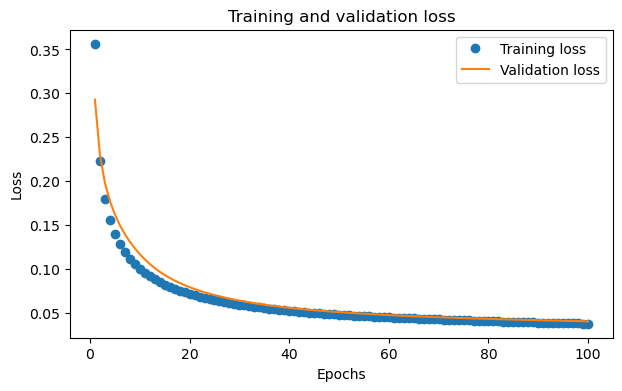

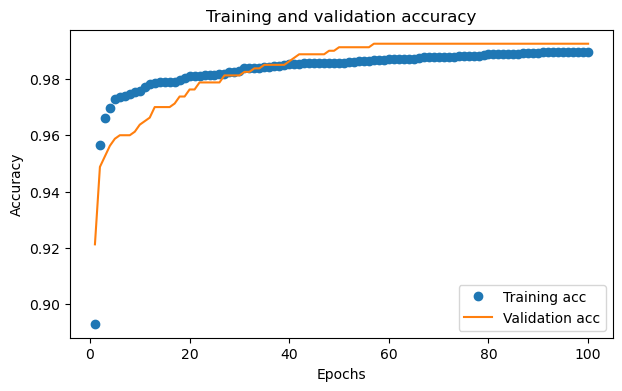

In [49]:

history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

# Loss
plt.figure(figsize=(7,4))
plt.plot(epochs, history_dict['loss'], 'o', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], '-', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.show()

# Accuracy
plt.figure(figsize=(7,4))
plt.plot(epochs, history_dict['accuracy'], 'o', label='Training acc')
plt.plot(epochs, history_dict['val_accuracy'], '-', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();
plt.show()

In [51]:
score = None
acc = None
# YOUR CODE HERE
score, acc = model.evaluate(X_test, y_test)
print({'test_loss': score, 'test_accuracy': acc})

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.9870 - loss: 0.0426
{'test_loss': 0.042580537497997284, 'test_accuracy': 0.9869999885559082}
